In [3]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt
!pip install roboflow

Cloning into 'yolov5'...
remote: Enumerating objects: 17783, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 17783 (delta 2), reused 1 (delta 1), pack-reused 17776 (from 2)
Receiving objects: 100% (17783/17783), 16.94 MiB | 14.81 MiB/s, done.
Resolving deltas: 100% (12130/12130), done.
/content/yolov5/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 49.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempti

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="GYiLvqoCXhBZ3NWSGyrR")
project = rf.workspace("modd2").project("pascal-voc-2007-bhjgf")
dataset = project.version(1).download("yolov5")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pascal-Voc-2007-1 in yolov5pytorch:: 100%|██████████| 10026/10026 [00:02<00:00, 4829.39it/s]


In [6]:
!python train.py \
  --img 256 \
  --batch 8 \
  --epochs 40 \
  --data Pascal-Voc-2007-1/data.yaml \
  --weights yolov5s.pt \
  --hyp data/hyps/hyp.scratch-low.yaml \
  --noautoanchor \
  --optimizer SGD


Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
      34/39     0.786G     0.0407    0.02673    0.01764         44        256:  37% 164/439 [00:24<00:37,  7.25it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      34/39     0.786G    0.04067    0.02671    0.01757         36        256:  38% 165/439 [00:24<00:38,  7.16it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      34/39     0.786G    0.04066    0.02667     0.0176         31        256:  38% 165/439 [00:24<00:38,  7.16it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with tor

In [10]:
!python detect.py \
  --weights runs/train/exp/weights/best.pt \
  --img 640 \
  --conf 0.25 \
  --source /content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000030_jpg.rf.0a5ff40bfd61228dce75a15ae12c28fc.jpg \
  --project runs/detect \
  --name vanilla_test \
  --exist-ok


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000030_jpg.rf.0a5ff40bfd61228dce75a15ae12c28fc.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=vanilla_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-457-g84ef1e59 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
image 1/1 /content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000030_jpg.rf.0a5ff40bfd61228dce75a15ae12c28fc.jpg: 640x640 1 bicycle, 2 persons, 11.6ms
Speed: 0.6ms pre-process, 11.6ms inference, 67.1ms NMS per image at sh

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

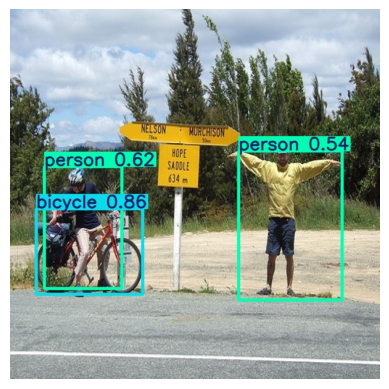

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/yolov5/yolov5/runs/detect/vanilla_test/000030_jpg.rf.0a5ff40bfd61228dce75a15ae12c28fc.jpg")
plt.imshow(img)
plt.axis("off")


In [13]:
!python detect.py \
  --weights runs/train/exp/weights/best.pt \
  --img 640 \
  --conf 0.25 \
  --source /content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000879_jpg.rf.2cdc830a4424e2c53f9349933f84cc9b.jpg \
  --project runs/detect \
  --name vanilla_test \
  --exist-ok


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000879_jpg.rf.2cdc830a4424e2c53f9349933f84cc9b.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=vanilla_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-457-g84ef1e59 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7064065 parameters, 0 gradients, 15.9 GFLOPs
image 1/1 /content/yolov5/yolov5/Pascal-Voc-2007-1/test/images/000879_jpg.rf.2cdc830a4424e2c53f9349933f84cc9b.jpg: 640x640 (no detections), 11.6ms
Speed: 0.5ms pre-process, 11.6ms inference, 39.8ms NMS per image at shape (

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

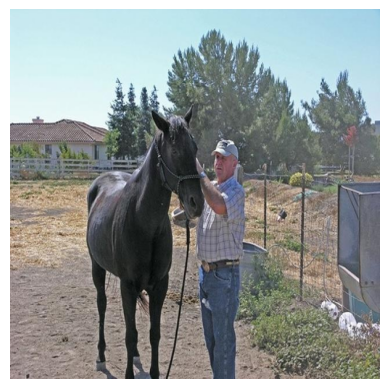

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/yolov5/yolov5/runs/detect/vanilla_test/000879_jpg.rf.2cdc830a4424e2c53f9349933f84cc9b.jpg")
plt.imshow(img)
plt.axis("off")
